In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('analytics_db.db')
cursor = conn.cursor()
print("Database connected successfully.")

Database connected successfully.


In [2]:
cursor.execute("DROP TABLE IF EXISTS customers;")

In [3]:
cursor.execute("""
CREATE TABLE customers (
    customer_id INTEGER PRIMARY KEY,
    customer_name TEXT NOT NULL,
    city TEXT NOT NULL,
    balance REAL NOT NULL
);
""")

In [5]:
fictional_data = [
    (1, 'Alice Anderson', 'New York', 1500.50),
    (2, 'Bob Bryan', 'Los Angeles', 2450.00),
    (3, 'Charlie Evans', 'New York', 3200.75),
    (4, 'Diana Smith', 'Chicago', 850.25),
    (5, 'Evan Thomson', 'Los Angeles', 125.00),
    (6, 'Fiona Grant', 'Chicago', 4100.00),
    (7, 'George Hanson', 'Boston', 2900.50),
    (8, 'Hannah Vance', 'Boston', 600.00)
]
cursor.executemany("""
INSERT INTO customers (customer_id, customer_name, city, balance) 
VALUES (?, ?, ?, ?);
""", fictional_data)

conn.commit()
print("Database initialized. Table successfully rebuilt with 8 rows.")

Database initialized. Table successfully rebuilt with 8 rows.


In [6]:
query_1 = "SELECT * FROM customers WHERE city = 'Boston';"
pd.read_sql_query(query_1, conn)

,customer_id,customer_name,city,balance
0,7,George Hanson,Boston,2900.5
1,8,Hannah Vance,Boston,600.0


In [7]:
query_2 = "SELECT * FROM customers ORDER BY balance DESC;"
pd.read_sql_query(query_2, conn)

,customer_id,customer_name,city,balance
0,6,Fiona Grant,Chicago,4100.00
1,3,Charlie Evans,New York,3200.75
2,7,George Hanson,Boston,2900.50
3,2,Bob Bryan,Los Angeles,2450.00
4,1,Alice Anderson,New York,1500.50
5,4,Diana Smith,Chicago,850.25
6,8,Hannah Vance,Boston,600.00
7,5,Evan Thomson,Los Angeles,125.00


In [8]:
query_3 = "SELECT * FROM customers WHERE customer_name LIKE '%an%';"
pd.read_sql_query(query_3, conn)

,customer_id,customer_name,city,balance
0,1,Alice Anderson,New York,1500.50
1,2,Bob Bryan,Los Angeles,2450.00
2,3,Charlie Evans,New York,3200.75
3,4,Diana Smith,Chicago,850.25
4,5,Evan Thomson,Los Angeles,125.00
5,6,Fiona Grant,Chicago,4100.00
6,7,George Hanson,Boston,2900.50
7,8,Hannah Vance,Boston,600.00


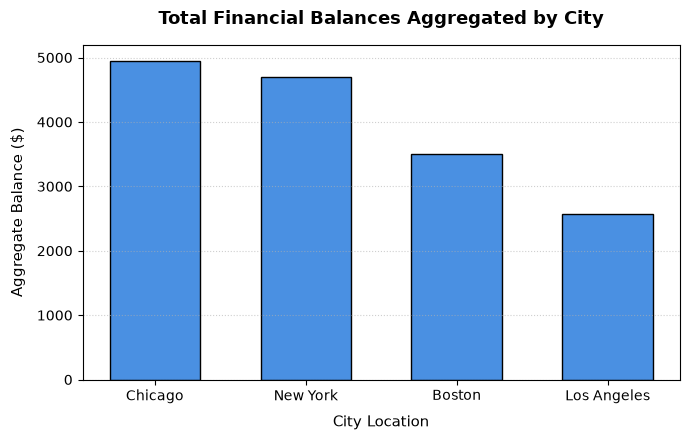

In [9]:
# 1. Aggregate balances by city
query_chart = """
SELECT city, SUM(balance) AS total_balance 
FROM customers 
GROUP BY city 
ORDER BY total_balance DESC;
"""
df_chart = pd.read_sql_query(query_chart, conn)

# 2. Plotting layout structure
plt.figure(figsize=(7, 4.5))
plt.bar(df_chart['city'], df_chart['total_balance'], color='#4a90e2', edgecolor='black', width=0.6)

# 3. Apply Module 5 / Lab 3 clear labels and title parameters
plt.title('Total Financial Balances Aggregated by City', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('City Location', fontsize=11, labelpad=8)
plt.ylabel('Aggregate Balance ($)', fontsize=11, labelpad=8)
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 4. Safely close connection
conn.close()